# Proyecto Final Deep Learning — MedGemma

## Evaluación multimodal mediante estudio de ablación

Este notebook presenta los **resultados obtenidos** en el proyecto final del Diplomado en Inteligencia Artificial Aplicada al Diagnóstico Médico.

El estudio evalúa MedGemma en un escenario zero-shot utilizando radiografías de tórax y reportes radiológicos, y compara tres configuraciones:

- **Original (Baseline):** imagen + texto original.
- **Image Shifting:** se modifica la modalidad visual.
- **Text Shifting:** se modifica la modalidad textual.

> **Nota de reproducibilidad:** esta versión está preparada para visualización pública en GitHub. No contiene tokens ni credenciales de Hugging Face. Los resultados corresponden a ejecuciones realizadas previamente.


## 1. Resultados del escenario original

Se muestran las predicciones y el reporte de clasificación obtenidos en el escenario **Original (Baseline)**.


,uid,filename,true_label,true_label_text,predicted_label,predicted_label_text,findings,raw_prediction,correct
0,2469,2469_IM-0999-3001.dcm.png,1,no normal,0,NORMAL,"There is mild XXXX opacification over both XXXX, XXXX secondary to soft tissue attenuation. There ar...","```json\n{\n ""normal_or_disease"": ""NORMAL""\n}\n```",0
1,2151,2151_IM-0771-1001.dcm.png,1,no normal,1,DISEASE,Hyperinflated lungs with flattened diaphragm and increased retrosternal airspace. No focal alveolar ...,"```json\n{\n ""normal_or_disease"": ""DISEASE""\n}\n```",1
2,2769,2769_IM-1212-2001.dcm.png,1,no normal,1,DISEASE,Cardiomediastinal silhouette are normal in size and contour. Again demonstrated are biapical bullous...,"```json\n{\n ""normal_or_disease"": ""DISEASE""\n}\n```",1
3,2640,2640_IM-1126-2001.dcm.png,0,normal,0,NORMAL,"The lungs are clear bilaterally. Specifically, no evidence of focal consolidation, pneumothorax, or ...","```json\n{\n ""normal_or_disease"": ""NORMAL""\n}\n```",1
4,2925,2925_IM-1327-1001.dcm.png,0,normal,0,NORMAL,The lungs are clear. The cardiomediastinal silhouette is within normal limits. No pleural effusion i...,"```json\n{\n ""normal_or_disease"": ""NORMAL""\n}\n```",1


,Unnamed: 0,precision,recall,f1-score,support
0,normal,0.534884,1.000000,0.696970,23.0000
1,no normal,1.000000,0.512195,0.677419,41.0000
2,accuracy,0.687500,0.687500,0.687500,0.6875
3,macro avg,0.767442,0.756098,0.687195,64.0000
4,weighted avg,0.832849,0.687500,0.684445,64.0000


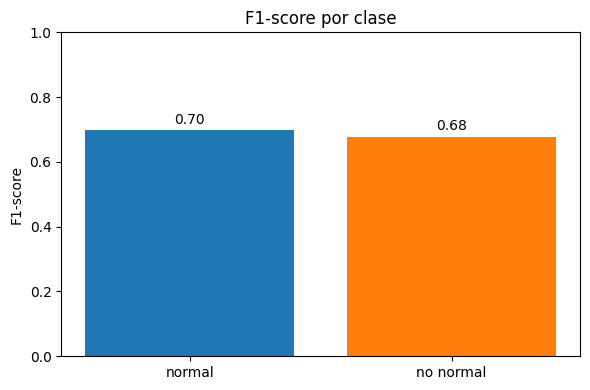

## 2. Resultados de los experimentos de ablación

Se presentan los resultados obtenidos para **Image Shifting** y **Text Shifting**.


  [LOG] Prediction received: 47 chars
  [LOG] True label: 0 (normal)
  [LOG] Predicted: NORMAL (✓)
[LOG] Processing sample 64/64: UID 3595
  [LOG] Loading MISMATCHED image: 943_IM-2439-3003.dcm.png instead of 3595_IM-1773-0001-0001.dcm.png
  [LOG] Image loaded. Using original findings length: 337 chars
  [LOG] Making prediction with mismatched image + original text...
  [LOG] Prediction received: 48 chars
  [LOG] True label: 1 (no normal)
  [LOG] Predicted: DISEASE (✓)

[LOG] Completed processing in 434.58 seconds

[LOG] Results Summary (IMAGE SHIFTING):
  - Total samples: 64
  - Accuracy (matching original text label): 60.94%
  - Correct predictions: 39
  - Incorrect predictions: 25

[LOG] Classification Report (F1, Precision, Recall):
              precision    recall  f1-score   support

      normal       0.48      0.87      0.62        23
   no normal       0.86      0.46      0.60        41

    accuracy                           0.61        64
   macro avg       0.67      0.67  

  [LOG] Prediction received: 48 chars
  [LOG] True label (Visual): 0 (normal)
  [LOG] Predicted: DISEASE (✗)
[LOG] Processing sample 64/64: UID 3595
  [LOG] Loading original image: 3595_IM-1773-0001-0001.dcm.png
  [LOG] Mismatched findings loaded from UID 1545. Length: 131 chars
  [LOG] Making prediction with original image + mismatched text...
  [LOG] Prediction received: 48 chars
  [LOG] True label (Visual): 1 (no normal)
  [LOG] Predicted: DISEASE (✓)

[LOG] Completed processing in 437.59 seconds

[LOG] Results Summary (TEXT SHIFTING):
  - Total samples: 64
  - Accuracy (matching original image label): 28.12%
  - Correct predictions: 18
  - Incorrect predictions: 46

[LOG] Classification Report (F1, Precision, Recall):
              precision    recall  f1-score   support

      normal       0.24      0.48      0.32        23
   no normal       0.37      0.17      0.23        41

    accuracy                           0.28        64
   macro avg       0.31      0.32      0.28       

## 3. Comparación de métricas

Comparación del comportamiento del modelo bajo las tres configuraciones experimentales.


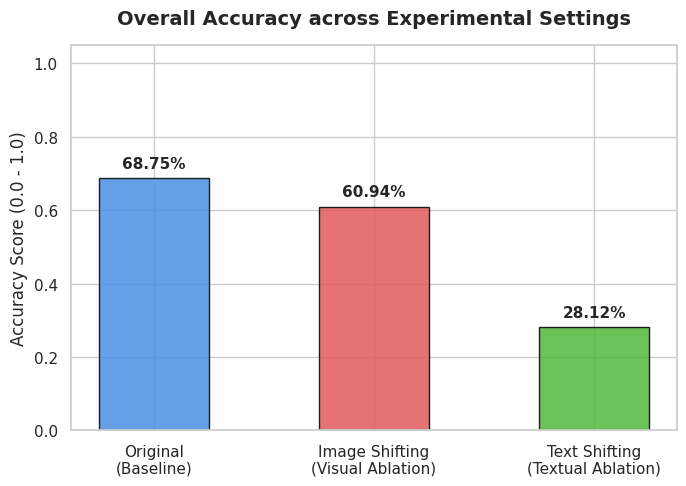

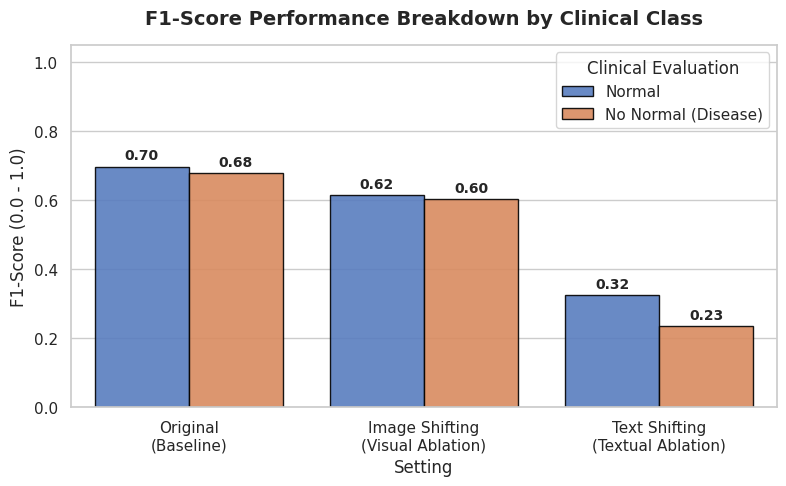


[INFO] ¡Gráficos generados con éxito! Se han guardado como 'ablation_overall_accuracy.png' y 'ablation_f1_score_by_class.png'.


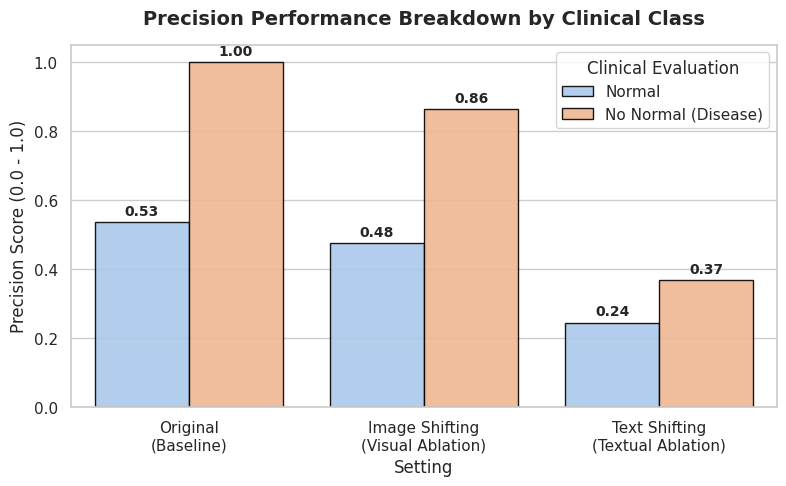

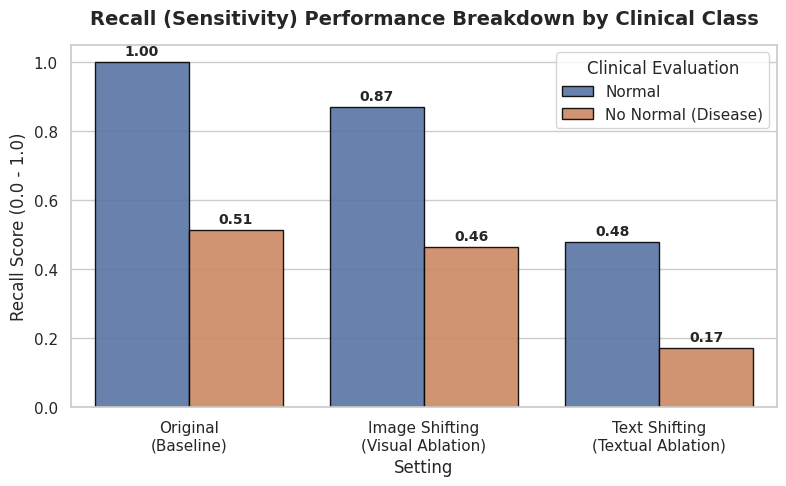


[INFO] ¡Nuevos gráficos generados con éxito! Guardados como 'ablation_precision_by_class.png' y 'ablation_recall_by_class.png'.



 TABLA COMPARATIVA GLOBAL DEL ESTUDIO DE ABLACIÓN



,Escenario Experimental,Overall Accuracy,Precision (Normal),Recall (Normal),F1-Score (Normal),Precision (No Normal),Recall (No Normal),F1-Score (No Normal)
0,Original (Baseline),68.75%,0.53,1.00,0.70,1.00,0.51,0.68
1,Image Shifting (Ablación Visual),60.94%,0.48,0.87,0.62,0.86,0.46,0.60
2,Text Shifting (Ablación Textual),28.12%,0.24,0.48,0.32,0.37,0.17,0.23


## 4. Interpretación de los resultados

### ¿Es suficientemente robusto para ser testeado en clínica?

**No.** La conclusión del proyecto es que MedGemma 1.5 no presenta suficiente robustez ni seguridad metodológica para ser testeado en un contexto clínico. El estudio identifica una dependencia importante entre las modalidades visual y textual, con cambios relevantes en el comportamiento del modelo cuando se altera una de ellas.

### ¿Qué debería demostrar antes de un testeo clínico?

El modelo debería demostrar, entre otros aspectos:

- robustez multimodal;
- resistencia al *modality shifting*;
- comportamiento estable ante discrepancias entre imagen y texto;
- evaluación rigurosa por clase y por escenario;
- validación en conjuntos de datos independientes;
- evidencia suficiente de seguridad y confiabilidad antes de cualquier uso clínico.

### Conclusión

El estudio muestra la importancia de evaluar no sólo el rendimiento promedio de un modelo multimodal, sino también **su sensibilidad a cambios deliberados en las modalidades de entrada**.
